# 01. SHAP Explanations

## 📚 Learning Objectives

By completing this notebook, you will:
- Use SHAP for model interpretability
- Interpret feature attributions and plots
- Communicate model behavior to stakeholders

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 01. SHAP Explanations

## 🚨 THE PROBLEM: AI Systems Are "Black Boxes"

**Remember the transition from Unit 3?**

We completed Unit 3: Privacy and Security, where we learned:
- How to protect data and ensure privacy
- How to comply with regulations
- How to build secure AI systems

**But there's a new challenge:**

**AI systems also raise transparency and accountability concerns!**

**The Problem**: As we build AI systems, we need to consider:
- ❌ **Transparency**: How do we explain AI decisions?
- ❌ **Accountability**: Who is responsible for AI outcomes?
- ❌ **Explainability**: How do we make AI understandable?
- ❌ **Auditability**: How do we track and verify AI behavior?

**We've learned:**
- ✅ How to build private and secure AI systems (Unit 3)
- ✅ How to ensure GDPR compliance
- ✅ How to protect data

**But we haven't learned:**
- ❌ How to **explain** AI model decisions
- ❌ How to **understand** why models make certain predictions
- ❌ How to **interpret** model behavior
- ❌ How to **provide explanations** to users

**We need explainability techniques** to:
1. Explain individual predictions (local explanations)
2. Understand overall model behavior (global explanations)
3. Identify important features
4. Make AI decisions transparent

**This notebook solves that problem** by teaching you SHAP (SHapley Additive exPlanations) for model interpretability!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 1: Ethics Foundations** - Understanding ethical principles
- ✅ **Unit 2: Bias and Justice** - Understanding fairness
- ✅ **Unit 3: Privacy and Security** - Understanding privacy and security
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Basic ML knowledge**: Model training, predictions, feature importance

**If you haven't completed these**, you might struggle with:
- Understanding why explainability matters
- Knowing how to interpret model predictions
- Understanding feature importance concepts

---

## 🔗 Where This Notebook Fits

**This is the FIRST example in Unit 4** - it teaches you how to explain AI decisions!

**Why this example FIRST?**
- **Before** you can use other explanation methods, you need to understand SHAP
- **Before** you can ensure accountability, you need explainability
- **Before** you can build transparent systems, you need explanation techniques

**Builds on**: 
- 📓 Unit 1: Ethics Foundations (ethical principles)
- 📓 Unit 2: Bias and Justice (fairness concepts)
- 📓 Unit 3: Privacy and Security (privacy and security)

**Leads to**: 
- 📓 Example 2: LIME Explanations (alternative explanation method)
- 📓 Example 3: Counterfactual Analysis (what-if explanations)
- 📓 Example 4: Accountability Frameworks (accountability structures)
- 📓 Example 5: Human-in-the-Loop (HITL approaches)
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. SHAP provides **foundation** for explainability (needed before other methods)
2. SHAP teaches **feature importance** (critical for understanding)
3. SHAP shows **local and global explanations** (essential for transparency)

---

## The Story: Opening the Black Box

Imagine you're a doctor using AI to diagnose patients. **Before** explainability, you'd get a diagnosis but wouldn't know why (black box!). **After** using SHAP, you can see which symptoms most influenced the diagnosis - transparent and understandable!

Same with AI: **Before** we have models that make predictions but we can't explain why, now we learn SHAP - calculate feature contributions to understand each prediction! **After** SHAP, we can explain why models make specific decisions!

---

## Why SHAP Explanations Matter

SHAP explanations are essential for ethical AI:
- **Transparency**: Understand why models make decisions
- **Trust**: Build user confidence through explanations
- **Debugging**: Identify model errors and biases
- **Compliance**: Meet explainability requirements
- **Accountability**: Enable responsibility for AI outcomes

## Learning Objectives
1. Understand SHAP values and their meaning
2. Learn how to calculate SHAP values
3. Generate local explanations for individual predictions
4. Generate global explanations for overall model behavior
5. Visualize SHAP explanations
6. Interpret SHAP results

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## Part 1: A Model to Explain

SHAP needs a model, so we first train a loan-approval classifier - the classic
"black box that owes people an explanation." Then we compute **SHAP values**: each
feature's contribution (positive or negative) to one specific prediction, based on
Shapley values from game theory.

In [1]:
# Why start here: explanation tools need a real trained model to interrogate -
# we build a loan-approval model whose true logic WE know, so we can check the explanations.

# Build a small loan-approval dataset and train the model we will explain
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 800
X = pd.DataFrame({
    'income':          np.random.normal(55, 18, n).clip(10, 150),     # k$/year
    'debt_ratio':      np.random.uniform(0.05, 0.6, n),               # debt/income
    'years_employed':  np.random.randint(0, 25, n),
    'credit_history':  np.random.normal(650, 80, n).clip(350, 850),   # score
})
# The ground-truth rule: approval is driven by income (+), debt (-),
# tenure (+), and credit history (+). Explanations should rediscover this.
score = (0.03*(X['income']-55) - 4.0*(X['debt_ratio']-0.3)
         + 0.05*X['years_employed'] + 0.008*(X['credit_history']-650))
y = (score + np.random.normal(0, 0.35, n) > 0).astype(int)   # 1 = approved

# Hold out a test set, then fit the classifier we will explain.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Loan-approval model trained. Test accuracy: "
      f"{accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"Approval rate in data: {y.mean():.1%}")

Loan-approval model trained. Test accuracy: 0.905
Approval rate in data: 66.0%


Global feature importance (mean |SHAP value|):
  debt_ratio      0.2042
  credit_history  0.1570
  income          0.1341
  years_employed  0.0537


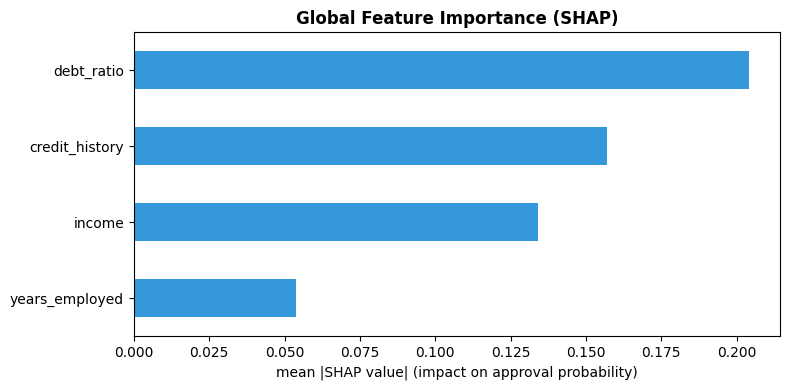


Applicant #0: approval probability 0.15
income             64.27
debt_ratio          0.41
years_employed      5.00
credit_history    503.33

SHAP contributions for THIS decision (+ pushes toward approval):
  credit_history  -0.3888
  debt_ratio      -0.1239
  income          +0.0870
  years_employed  -0.0863


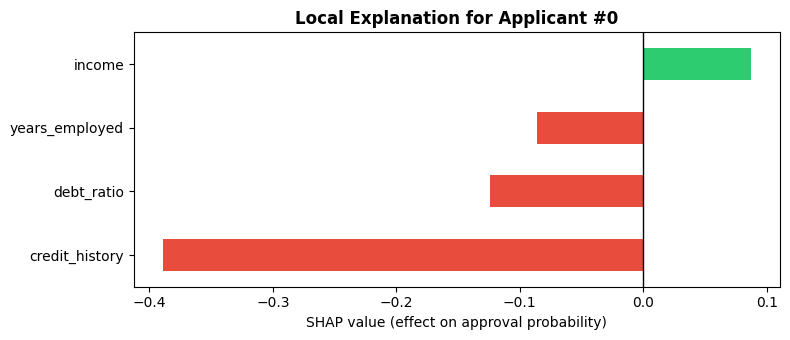


Reading it: green bars pushed this applicant toward approval, red bars
toward denial. SHAP values are additive - they sum (with the base rate)
to the model's output for this applicant.


In [2]:
# Why SHAP: it assigns each feature a fair, additive share of the prediction
# (Shapley values from game theory) - one method gives global AND local views.

# Step 2: Compute SHAP values - global and local explanations
import shap
import matplotlib.pyplot as plt

# TreeExplainer computes exact Shapley values efficiently for tree ensembles.
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_test)
# Normalize across shap versions: get values for class 1 ("approved")
if isinstance(sv, list):
    sv1 = sv[1]
elif sv.ndim == 3:
    sv1 = sv[:, :, 1]
else:
    sv1 = sv

# --- GLOBAL explanation: mean |SHAP| per feature ---
importance = pd.Series(np.abs(sv1).mean(axis=0), index=X_test.columns
                       ).sort_values()
print("Global feature importance (mean |SHAP value|):")
for feat, val in importance.sort_values(ascending=False).items():
    print(f"  {feat:<15} {val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot.barh(ax=ax, color='#3498db')
ax.set_xlabel('mean |SHAP value| (impact on approval probability)')
ax.set_title('Global Feature Importance (SHAP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- LOCAL explanation: why was applicant #0 decided this way? ---
i = 0
applicant = X_test.iloc[i]
proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
print(f"\nApplicant #{i}: approval probability {proba:.2f}")
print(applicant.round(2).to_string())
contrib = pd.Series(sv1[i], index=X_test.columns).sort_values()
print("\nSHAP contributions for THIS decision (+ pushes toward approval):")
for feat, val in contrib.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:<15} {val:+.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in contrib]
contrib.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('SHAP value (effect on approval probability)')
ax.set_title(f'Local Explanation for Applicant #{i}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nReading it: green bars pushed this applicant toward approval, red bars")
print("toward denial. SHAP values are additive - they sum (with the base rate)")
print("to the model's output for this applicant.")

---

## 🚫 When SHAP Explanations Hit a Limitation

### The Limitation We Discovered

We've learned SHAP for explaining model predictions. **But there's still a challenge:**

**What if we need a simpler, faster explanation method that works with any model?**

SHAP works well when:
- ✅ We need mathematically rigorous explanations
- ✅ We can afford computational cost
- ✅ We want feature importance based on game theory

**But sometimes we need:**
- ❌ **Faster explanations** (SHAP can be slow for large datasets)
- ❌ **Simpler methods** (easier to understand and implement)
- ❌ **Model-agnostic approaches** (work with any black-box model)
- ❌ **Local explanations** (explain individual predictions quickly)

### Why This Is a Problem

When SHAP is too slow or complex:
- We may need faster explanations for real-time systems
- We may want simpler methods for non-technical users
- We may need alternatives for different use cases
- We may want to compare different explanation methods

### The Solution: LIME Explanations

We need **LIME (Local Interpretable Model-agnostic Explanations)** to:
1. Provide fast local explanations
2. Work with any black-box model
3. Offer simpler, more intuitive explanations
4. Enable real-time explainability

**This is exactly what we'll learn in the next notebook: LIME Explanations!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP for model explanations
- ✅ How to generate local and global explanations
- ✅ **The limitation**: We need faster, simpler alternatives!

**Next notebook**: `02_lime_explanations.ipynb`
- Learn about LIME for fast local explanations
- Understand model-agnostic explainability
- Compare SHAP vs LIME approaches

## 📚 References

1. Shapley, L. S. (1953). *A Value for n-Person Games*. In: Contributions to the Theory of Games II. Princeton University Press. (the game-theoretic foundation)
2. Lundberg, S. M. & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017. <https://arxiv.org/abs/1705.07874>
3. Slack, D., Hilgard, S., Jia, E., Singh, S. & Lakkaraju, H. (2020). *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods*. AIES 2020. <https://arxiv.org/abs/1911.02508>
4. Molnar, C. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (online book). <https://christophm.github.io/interpretable-ml-book/>